In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
import pandas as pd
df = pd.read_csv(r"data\UPL.csv")

In [4]:
df.shape

(4287, 15)

In [5]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2004-01-23,UNIPHOS,EQ,10.00,100.0,560.0,100.0,555.1,553.80,483.69,73629,3.561361e+12,NaN,52799.0,0.7171
1,2004-01-27,UNIPHOS,EQ,553.80,570.0,570.0,525.0,530.1,540.35,540.77,26737,1.445851e+12,NaN,17314.0,0.6476
2,2004-01-28,UNIPHOS,EQ,540.35,530.0,565.0,511.0,542.0,538.85,542.24,32155,1.743569e+12,NaN,23285.0,0.7241
3,2004-01-29,UNIPHOS,EQ,538.85,530.0,543.5,504.0,517.0,515.10,529.23,19074,1.009447e+12,NaN,12935.0,0.6781
4,2004-01-30,UNIPHOS,EQ,515.10,519.0,519.0,471.4,485.0,482.95,485.85,23807,1.156659e+12,NaN,12750.0,0.5356


In [6]:
# Removing duplicates from date feature
df = df.drop_duplicates(subset='Date',keep='last')

In [7]:
df = df.sort_values("Date").reset_index(drop=True)

In [8]:
numeric_df = df.iloc[:, 3:-1]

In [9]:
numeric_df.shape

(4287, 11)

In [10]:
numeric_df.isnull().sum()

Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                1831
Deliverable Volume       6
dtype: int64

In [11]:
numeric_df = numeric_df.apply(pd.to_numeric,errors='coerce')
numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df = numeric_df.ffill().bfill()

In [12]:
numeric_df.isnull().sum()

Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

In [13]:
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,10.00,100.0,560.0,100.0,555.1,553.80,483.69,73629,3.561361e+12,12416.0,52799.0
1,553.80,570.0,570.0,525.0,530.1,540.35,540.77,26737,1.445851e+12,12416.0,17314.0
2,540.35,530.0,565.0,511.0,542.0,538.85,542.24,32155,1.743569e+12,12416.0,23285.0
3,538.85,530.0,543.5,504.0,517.0,515.10,529.23,19074,1.009447e+12,12416.0,12935.0
4,515.10,519.0,519.0,471.4,485.0,482.95,485.85,23807,1.156659e+12,12416.0,12750.0


In [14]:
print(numeric_df.dtypes)

Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume    float64
dtype: object


In [15]:
print(numeric_df.columns)

Index(['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume',
       'Turnover', 'Trades', 'Deliverable Volume'],
      dtype='str')


In [16]:
feature_names = numeric_df.columns.tolist()
print("Features used:", feature_names)

data = numeric_df.values
num_features = data.shape[1] #No. of features in the dataset
print("No. of features: ",num_features)

print("Shape:", data.shape)

Features used: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']
No. of features:  11
Shape: (4287, 11)


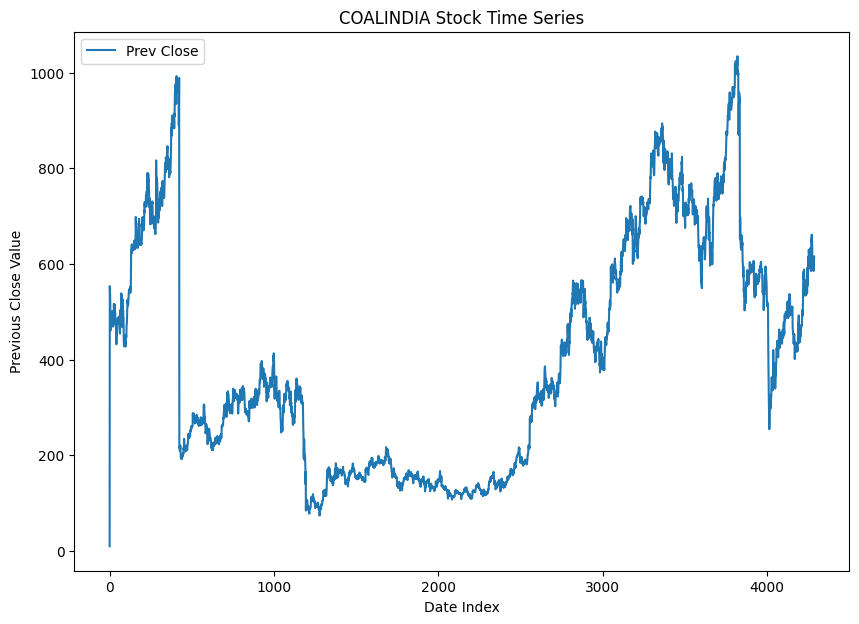

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.plot(numeric_df.index, numeric_df[feature_names[0]], label=feature_names[0])

# Titles and labels
plt.title('COALINDIA Stock Time Series')
plt.xlabel('Date Index')
plt.ylabel('Previous Close Value')

plt.legend()
plt.show()

In [18]:
data = numeric_df.values.astype(np.float32)
print("Data Shape:", data.shape)

Data Shape: (4287, 11)


In [19]:
# Train/Test split: 80/20
TRAIN_RATIO = 0.8
split_idx = int(len(data) * TRAIN_RATIO)

train_data_temp = data[:split_idx]
test_data = data[split_idx:]

# split train into train and validation sets (80:20)
val_split_idx = int(len(train_data_temp) * 0.8)

train_data = train_data_temp[:val_split_idx]
val_data = train_data_temp[val_split_idx:]

In [20]:
test_data.shape, train_data.shape, val_data.shape

((858, 11), (2743, 11), (686, 11))

In [21]:
train_norms = np.linalg.norm(train_data, axis=0)
test_norms = np.linalg.norm(test_data, axis=0)


In [22]:
from sklearn.preprocessing import normalize

#axis=0 for column-wise normalization
train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

In [39]:
INPUT_STEPS = 10
OUTPUT_STEPS = 5
BATCH_SIZE = 4
OVERLAP = 5

In [40]:
#input_steps: number of past time steps used as input=10
#output_steps: number of future time steps to predict=5


def create_sequences(data_array, input_steps=INPUT_STEPS, output_steps=OUTPUT_STEPS, overlap=1):
    X, y = [], []
    total_len = len(data_array)

    stride = input_steps - overlap
    if stride <= 0:
        raise ValueError("overlap must be smaller than input_steps")

    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps : i + input_steps + output_steps])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [41]:
X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, OVERLAP)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, OVERLAP)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, OVERLAP)

print("X_train Shape :", X_train.shape, "| y_train Shape :", y_train.shape)
print("X_test Shape :", X_test.shape, "| y_test Shape :", y_test.shape)
print("X_val Shape :", X_val.shape, "| y_val Shape :", y_val.shape)

X_train Shape : (546, 10, 11) | y_train Shape : (546, 5, 11)
X_test Shape : (169, 10, 11) | y_test Shape : (169, 5, 11)
X_val Shape : (135, 10, 11) | y_val Shape : (135, 5, 11)


In [42]:
from torch.utils.data import Dataset
import torch

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [43]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
val_dataset = TimeSeriesDataset(X_val, y_val)

In [44]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [45]:
import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(11, 10, batch_first=True)
        self.fc = nn.Linear(10, 5 * 11)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, 11)

In [46]:
import torch

model = LSTMForecaster().to(device)

lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion_MSE = nn.MSELoss()
criterion_MAE = nn.L1Loss()

def RMSELoss(y_pred, y_true):
    mse = nn.MSELoss()(y_pred, y_true)
    rmse = torch.sqrt(mse)
    return rmse

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=10
)

In [47]:
def train_one_epoch_MSE(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion_MSE(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [48]:
def evaluate_MSE(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion_MSE(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

In [49]:
#Training with early stopping based on validation loss
EPOCHS = 200
PATIENCE = 20  # stop if no improvement for 20 epochs
train_losses_MSE = []
val_losses_MSE = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_MSE(model, train_loader, optimizer, criterion_MSE, device)
    val_loss, _, _ = evaluate_MSE(model, val_loader, criterion_MSE, device)

    train_losses_MSE.append(train_loss)
    val_losses_MSE.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # optional: save best model
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/200] | Train Loss: 0.043030 | Val Loss: 0.038001
Epoch [2/200] | Train Loss: 0.031535 | Val Loss: 0.027252
Epoch [3/200] | Train Loss: 0.021604 | Val Loss: 0.017686
Epoch [4/200] | Train Loss: 0.013411 | Val Loss: 0.010573
Epoch [5/200] | Train Loss: 0.007724 | Val Loss: 0.006092
Epoch [6/200] | Train Loss: 0.004205 | Val Loss: 0.003507
Epoch [7/200] | Train Loss: 0.002227 | Val Loss: 0.002123
Epoch [8/200] | Train Loss: 0.001184 | Val Loss: 0.001397
Epoch [9/200] | Train Loss: 0.000648 | Val Loss: 0.001022
Epoch [10/200] | Train Loss: 0.000382 | Val Loss: 0.000825
Epoch [11/200] | Train Loss: 0.000256 | Val Loss: 0.000765
Epoch [12/200] | Train Loss: 0.000199 | Val Loss: 0.000703
Epoch [13/200] | Train Loss: 0.000175 | Val Loss: 0.000688
Epoch [14/200] | Train Loss: 0.000165 | Val Loss: 0.000693
Epoch [15/200] | Train Loss: 0.000161 | Val Loss: 0.000668
Epoch [16/200] | Train Loss: 0.000158 | Val Loss: 0.000688
Epoch [17/200] | Train Loss: 0.000157 | Val Loss: 0.000653
Epoch 

In [50]:
# evaluation of model on Test dataset using MSE Loss
test_loss_MSE, predictions_MSE, targets = evaluate_MSE(model, test_loader, criterion_MSE, device)
print("\nFinal Test Loss:", test_loss_MSE)


Final Test Loss: 0.00022639369376116714


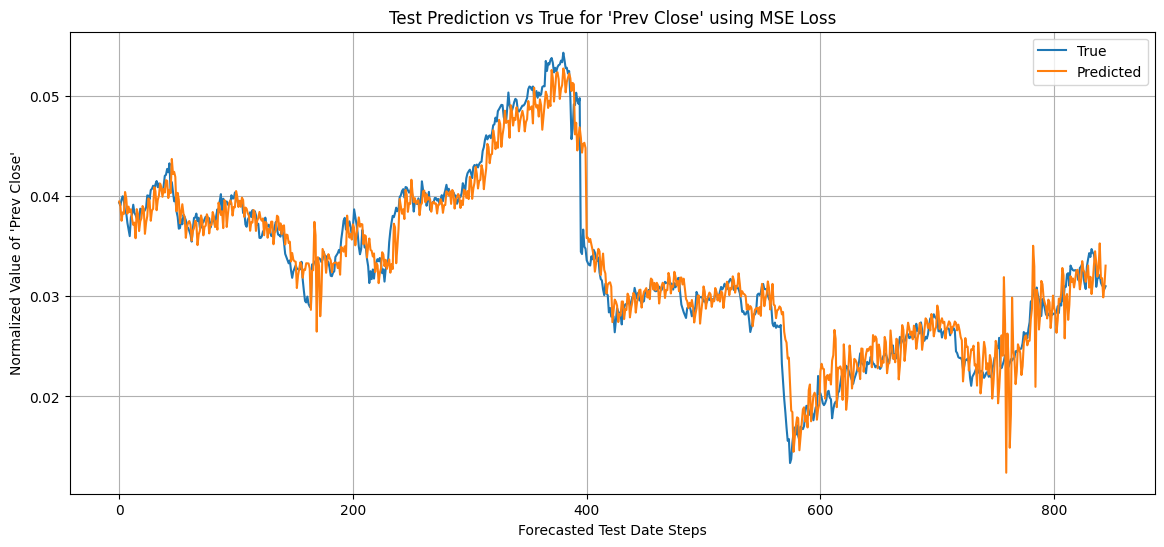

In [51]:
# Plot predictions vs targets values using MSE Loss
PLOT_FEATURE = "Prev Close" 

if PLOT_FEATURE not in feature_names:
    raise ValueError(f"{PLOT_FEATURE} not found. Choose from: {feature_names}")

feature_idx = feature_names.index(PLOT_FEATURE)

pred_feature = predictions_MSE[:, :, feature_idx].reshape(-1)
true_feature = targets[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 6))
plt.plot(true_feature, label="True")
plt.plot(pred_feature, label="Predicted")

plt.title(f"Test Prediction vs True for '{PLOT_FEATURE}' using MSE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of '{PLOT_FEATURE}'")

plt.legend()
plt.grid(True)
plt.show()

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []

for i, feature in enumerate(feature_names):
    # y_true = targets[:, :, i].reshape(-1)
    # y_pred = predictions[:, :, i].reshape(-1)
    y_true = targets[:, :, i].reshape(-1)
    y_pred = predictions_MSE[:, :, i].reshape(-1)

    results.append({
        "Feature": feature,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    })

metrics_df = pd.DataFrame(results)
metrics_df

,Feature,RMSE,MAE,MSE,R2
0,Prev Close,0.002188,0.001539,0.000005,0.932072
1,Open,0.002054,0.001383,0.000004,0.939593
2,High,0.002337,0.001551,0.000005,0.919945
3,Low,0.002307,0.001536,0.000005,0.925611
4,Last,0.002574,0.001807,0.000007,0.905865
5,Close,0.002149,0.001475,0.000005,0.934462
6,VWAP,0.002088,0.001493,0.000004,0.937470
7,Volume,0.026089,0.012035,0.000681,0.030370
8,Turnover,0.025495,0.012588,0.000650,-0.070696
9,Trades,0.021183,0.010900,0.000449,0.041528


In [53]:
targets_denorm = targets * test_norms
predictions_MSE_denorm = predictions_MSE * test_norms

y_true = targets_denorm[:, :, feature_idx]
y_pred = predictions_MSE_denorm[:, :, feature_idx]

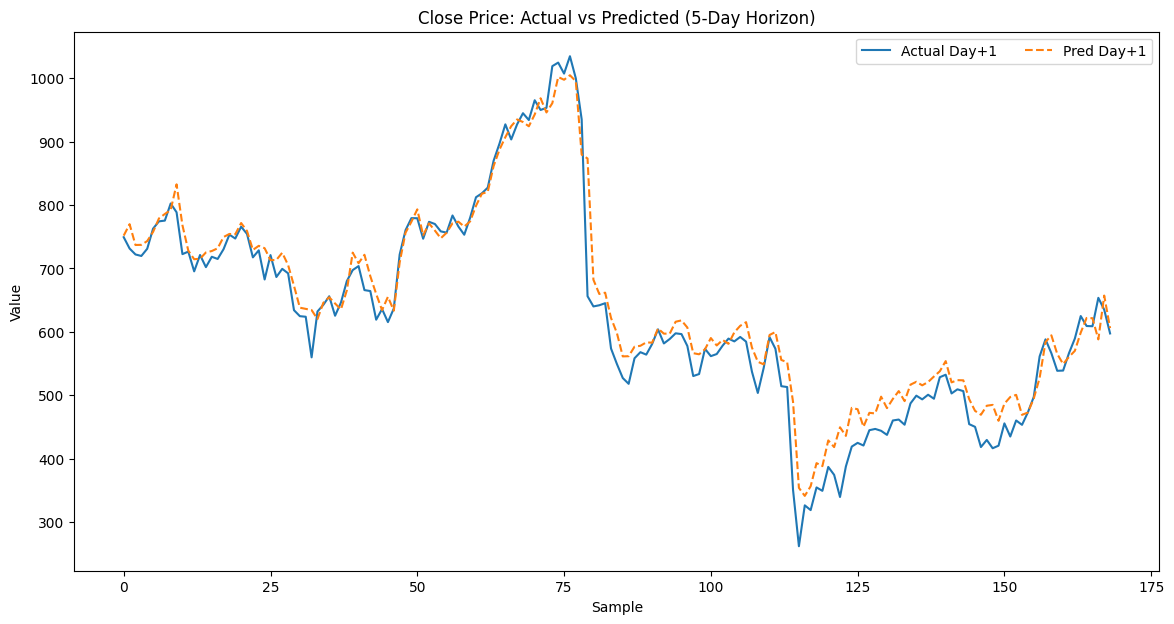

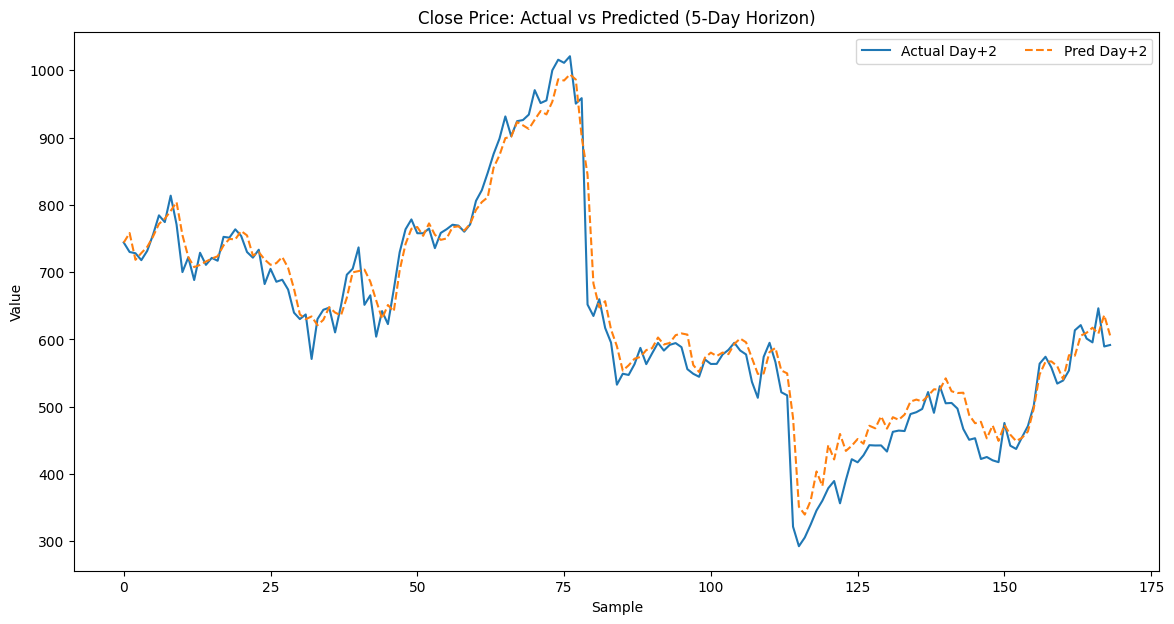

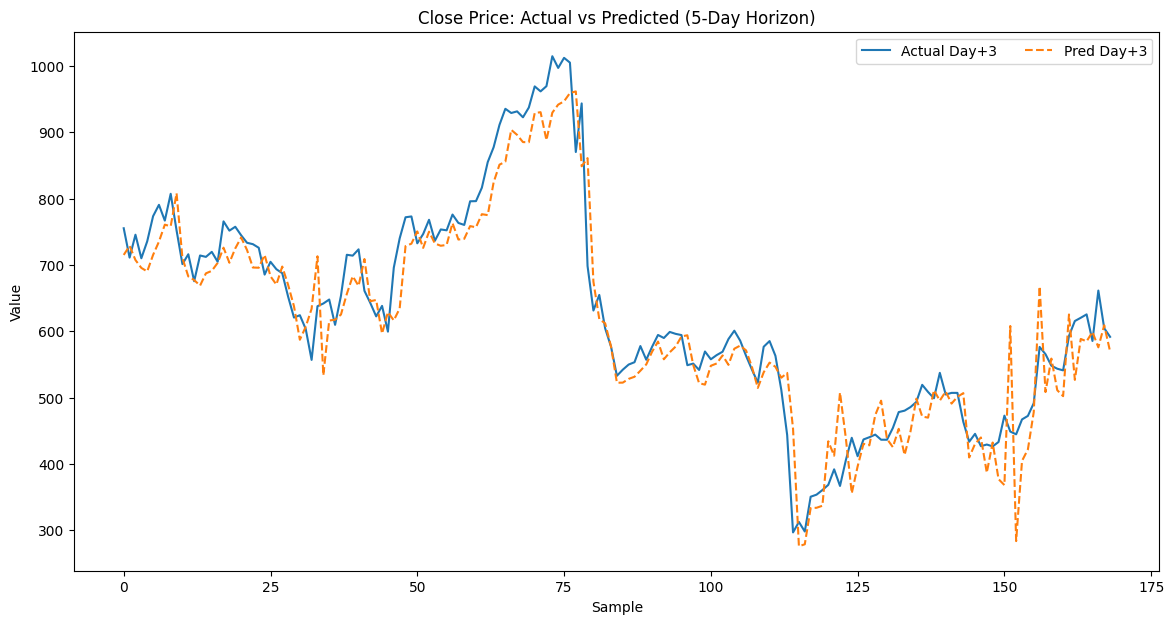

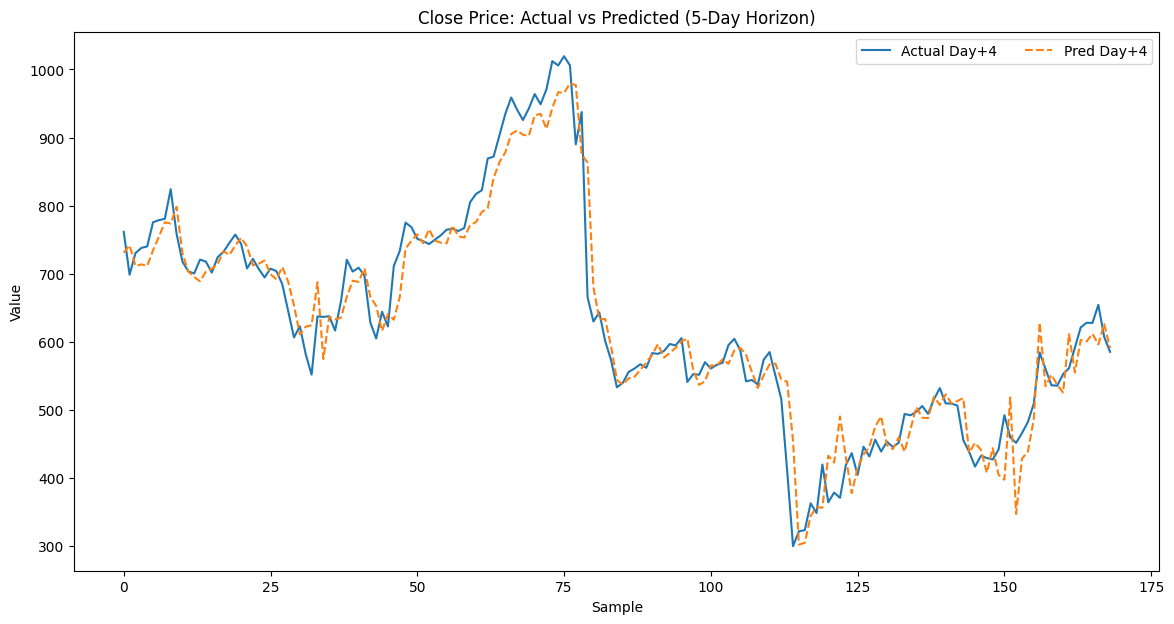

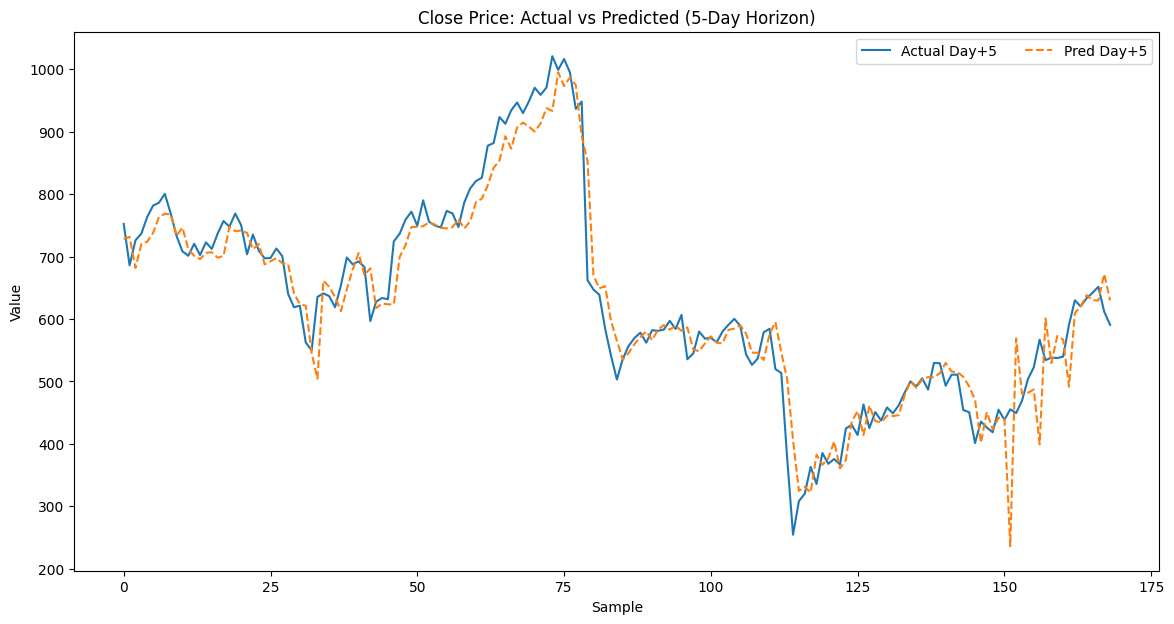

In [54]:
for day in range(OUTPUT_STEPS):
    plt.figure(figsize=(14, 7))
    plt.plot(y_true[:, day], label=f'Actual Day+{day+1}')
    plt.plot(y_pred[:, day], '--', label=f'Pred Day+{day+1}')

    plt.title('Close Price: Actual vs Predicted (5-Day Horizon)')
    plt.xlabel('Sample')
    plt.ylabel('Value')
    plt.legend(ncol=2)
    plt.show()